## Bland-Altman analysis to investigate intra-scanner variability of SC

In [15]:
import h5py
import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean
from simulate_sc import (
    simulate_sc_length_bias,
    simulate_sc_density_bias,
    simulate_sc_fns,
    simulate_sc_fps,
)
from ba_plot import ba_plot

atlas_path = "/data/probconnatlas/wm.connatlas.scale1.h5"

### Simulate SC matrices with a set biases
We will use simulated SC matrices with an artifical set bias in the within-scanner variability to develop a Bland-Altman analysis capable of detecting such biases. 
Once the methodology is refined, we will apply it on the real HCPh data.

In [16]:
SC_matrices = simulate_sc_length_bias(atlas_path=atlas_path)
num_sessions = SC_matrices.shape[0]
atlas_dim = SC_matrices.shape[1]

Using the connectome atlas as reference SC matrix.
Simulated a series of 36 SC matrices of shape (95x95) with higher variability (std=0.5) in long connections.


### Prepare the dataframe to input into the Bland-Altman analyses

We first prepare an SC matrices array by keeping only the lower triangle of each SC matrix and unravel it into a row vector.

In [17]:
# Extract the lower triangle of each SC matrix and unravel it into a row vector
SC_matrices_tril = np.array(
    [SC_matrices[i][np.tril_indices(atlas_dim, k=-1)] for i in range(num_sessions)]
)

print(SC_matrices_tril.shape)
# Test whether the shape is as expected
assert SC_matrices_tril.shape == (num_sessions, atlas_dim * (atlas_dim - 1) // 2)

(36, 4465)


We randomly assign half of the session to one group and the other half to another group. We will consider those two random groups as our two methods of measurements. Once the group assignement is made, we count the repetition index of each session within the group. Finally, we combine all these information in a dataframe.

In [18]:
def assign_repl(random_group):
    # DO WE NEED TO RANDOMIZE REPLICATION ASSIGNEMENT OR WE PRESERVE THE ORIGINAL SESSION ORDER (= what we do for now)?
    # Generate a vector that establishes the repetition index based on random group assignment
    count_group2 = np.cumsum(random_group == 2)
    indices1 = np.where(random_group == 1)
    count_group2[indices1] = 0

    count_group1 = np.cumsum(random_group == 1)
    indices2 = np.where(random_group == 2)
    count_group1[indices2] = 0
    repl = count_group1 + count_group2

    return repl


# Randomly assign half of the sessions to one group and half to another, we will consider those two random groups as our two methods of measurement
random_group = np.random.permutation(
    [1] * int(num_sessions / 2) + [2] * int(num_sessions / 2)
)  # DO WE NEED THIS TO BE REPRODUCIBLE OR NOT?
# Establish the repetition index
repl = assign_repl(random_group)
print(f"Random group vector: {random_group}")
print(f"Replication vector: {repl}")
# Test if the function behaves as it should
assert np.array_equal(
    assign_repl(np.array([2, 2, 1, 2, 1, 2])), [1, 2, 1, 3, 2, 4]
), f"{assign_repl([2, 2, 1, 2, 1, 2])} != [1, 2, 1, 3, 2, 4], establishement of repetition index is broken"

Random group vector: [1 1 1 1 2 2 2 2 1 2 1 2 2 2 2 2 1 1 2 1 2 1 2 2 2 2 1 1 1 1 1 1 2 1 2 1]
Replication vector: [ 1  2  3  4  1  2  3  4  5  5  6  6  7  8  9 10  7  8 11  9 12 10 13 14
 15 16 11 12 13 14 15 16 17 17 18 18]


In [19]:
# Create a DataFrame combining random_group, repl, and SC_matrices_tril
df_sc = pd.DataFrame(
    SC_matrices_tril,
    columns=[f"connection_{i}" for i in range(SC_matrices_tril.shape[1])],
)
df_sc.insert(0, "random_group", random_group)
df_sc.insert(1, "replication", repl)

print(df_sc)

    random_group  replication  connection_0  connection_1  connection_2  \
0              1            1    701.176932    391.763041     35.754290   
1              1            2    701.249108    391.894300     35.713583   
2              1            3    701.341545    391.999376     35.817164   
3              1            4    701.237667    391.851466     35.802039   
4              2            1    701.033863    391.833478     35.688732   
5              2            2    701.087946    391.951936     35.748554   
6              2            3    701.282398    391.732030     35.765073   
7              2            4    701.222492    392.016228     35.673605   
8              1            5    701.194833    391.715159     35.732168   
9              2            5    701.240626    391.869357     35.739611   
10             1            6    701.262959    391.904470     35.786456   
11             2            6    701.311332    391.950448     35.704279   
12             2         

In [20]:
import statsmodels.formula.api as smf

df = df_sc.melt(
    id_vars=["random_group", "replication"],
    var_name="connection_index",
    value_name="sc",
)

# Replace NaN values in the 'sc' column with zero
df["sc"].fillna(0, inplace=True)

df.to_csv("sc_dataframe_for_R.csv", index=False)
print(df)

# md = smf.mixedlm("sc ~ random_group + connection_index", df, groups= df["connection_index"], re_formula='0 + random_group')
# mdf = md.fit()
# print(mdf.summary())

        random_group  replication connection_index          sc
0                  1            1     connection_0  701.176932
1                  1            2     connection_0  701.249108
2                  1            3     connection_0  701.341545
3                  1            4     connection_0  701.237667
4                  2            1     connection_0  701.033863
...              ...          ...              ...         ...
160735             1           16  connection_4464  168.722104
160736             2           17  connection_4464  168.581681
160737             1           17  connection_4464  168.610152
160738             2           18  connection_4464  168.620785
160739             1           18  connection_4464  168.556518

[160740 rows x 4 columns]


### Compute all pair-wise session comparison

We compute all pairwise subtractions of sessions (that is rows in SC_matrices) and normalize it by the average difference of that connection.

In [21]:
# Convert NaN to zeros to correctly compute differences
SC_matrices_tril[np.isnan(SC_matrices_tril)] = 0

# Compute absolute value of pairwise subtractions for unique pairs (i, j) where i < j
sessions_subtractions = []
session_pairs = []

# Choose whether to compute differences in absolute value sor not
absolute_diff = True
if absolute_diff:
    num_sub = num_sessions * (num_sessions - 1) // 2
else:
    num_sub = num_sessions * num_sessions

j_range = range(num_sessions)
for i in range(num_sessions):
    j_range = range(i + 1, num_sessions) if absolute_diff else range(num_sessions)
    for j in j_range:
        subtraction = SC_matrices_tril[i] - SC_matrices_tril[j]
        if absolute_diff:
            subtraction = np.abs(subtraction)
        sessions_subtractions.append(subtraction)
        session_pairs.append((i, j))

sessions_subtractions = np.array(sessions_subtractions)
assert sessions_subtractions.shape == (
    num_sub,
    atlas_dim * (atlas_dim - 1) // 2,
)

# Normalize the subtractions by the grand mean value of each connection
grand_mean = np.mean(sessions_subtractions, axis=0)
# Divide by connection grand mean only if it is not zero
non_zero_indices = np.where(grand_mean != 0)[0]
assert grand_mean.shape == (atlas_dim * (atlas_dim - 1) // 2,)
sessions_subtractions[:, non_zero_indices] = (
    sessions_subtractions[:, non_zero_indices] / grand_mean[non_zero_indices]
)
assert sessions_subtractions.shape == (
    num_sub,
    atlas_dim * (atlas_dim - 1) // 2,
)

Let's now compute all pairwise means of two sessions

In [22]:
# Compute all pairwise mean for unique pairs (i, j) where i < j
sessions_means = []
for i in range(num_sessions):
    j_range = range(i + 1, num_sessions) if absolute_diff else range(num_sessions)
    for j in j_range:
        means = np.mean(np.vstack((SC_matrices_tril[i], SC_matrices_tril[j])), axis=0)
        sessions_means.append(means)

sessions_means = np.array(sessions_means)
assert sessions_means.shape == (
    num_sub,
    atlas_dim * (atlas_dim - 1) // 2,
)
assert sessions_means.shape == sessions_subtractions.shape

We will also try to compute the euclidean distance between pairs of SC matrices

In [23]:
# Compute absolute value of pairwise subtractions for unique pairs (i, j) where i < j
sessions_dist = []

j_range = range(num_sessions)
for i in range(num_sessions):
    for j in range(i + 1, num_sessions):
        distance = euclidean(SC_matrices_tril[i], SC_matrices_tril[j])
        sessions_dist.append(distance)

sessions_dist = np.array(sessions_dist)
assert sessions_dist.shape == (num_sub,)

## Pre-registered analysis

Plot the BA plot for the ten connections with the largest pairwise differences (normalized by the average difference in the pool).


#### Identify the connections corresponding to the 10 largest differences

In [24]:
# Identify the 10 maximum element-wise subtractions in sessions_subtractions
max_indices = np.unravel_index(
    np.argsort(np.abs(sessions_subtractions), axis=None)[-10:],
    sessions_subtractions.shape,
)
max_values = sessions_subtractions[max_indices]
# Verify that we indeed extract the 10 maximum differences
assert abs(np.min(max_values)) > np.abs(
    np.max(
        np.ma.masked_array(
            sessions_subtractions, mask=np.isin(sessions_subtractions, max_values)
        )
    )
)

print(
    f"The 10 biggest differences in a structural connection value between two sessions are: {max_values}"
)
# Extract the session pairs corresponding to the 10 biggest differences
max_session_pairs = [session_pairs[idx] for idx in max_indices[0]]

print(
    f"The session pairs corresponding to the 10 biggest differences are: {max_session_pairs}"
)
print(
    f"The connection corresponding to the 10 biggest differences are {max_indices[1]}"
)  # TO DO: match connections indices to the brain regions

The 10 biggest differences in a structural connection value between two sessions are: [5.5250897  5.55562485 5.57196298 5.58341649 5.58784429 5.62594746
 5.64444603 5.65982529 6.02298957 6.07334793]
The session pairs corresponding to the 10 biggest differences are: [(10, 30), (18, 35), (7, 18), (21, 26), (6, 27), (4, 32), (5, 10), (18, 26), (29, 35), (18, 25)]
The connection corresponding to the 10 biggest differences are [3677 3724 3724 3034 1691  125  513 3034 4043 2624]


#### Plot the BA plot of the connections with the biggest differences

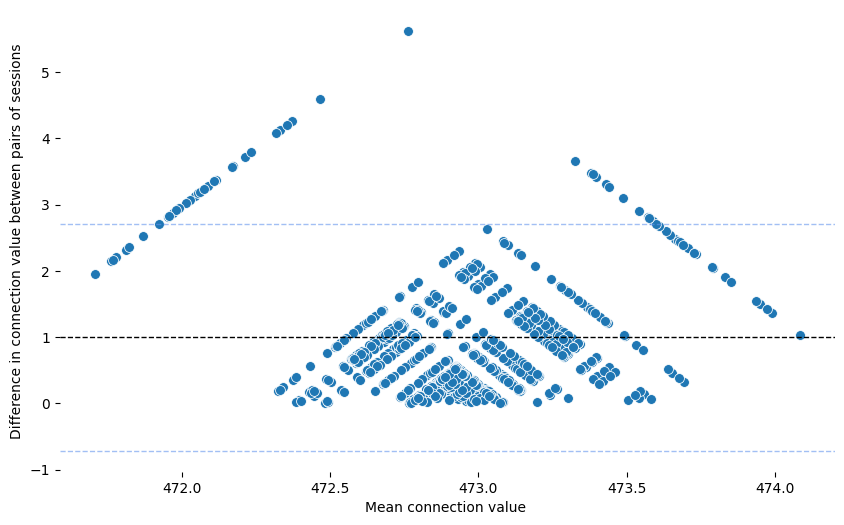

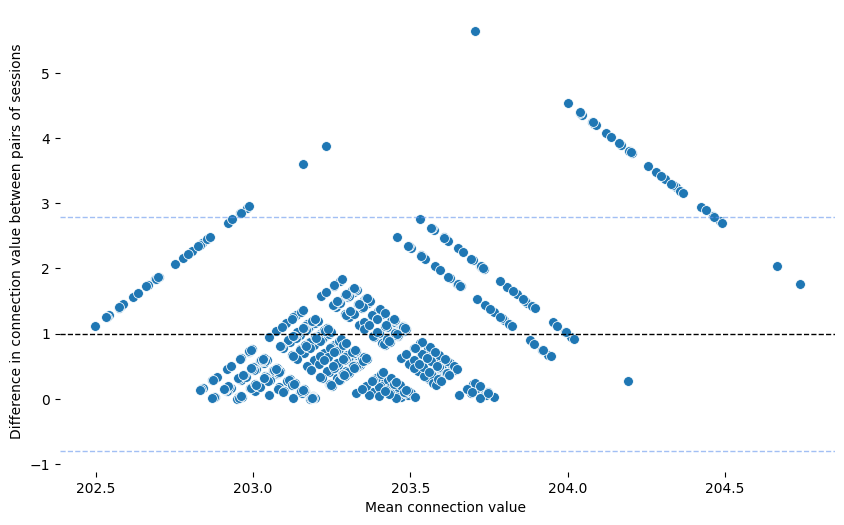

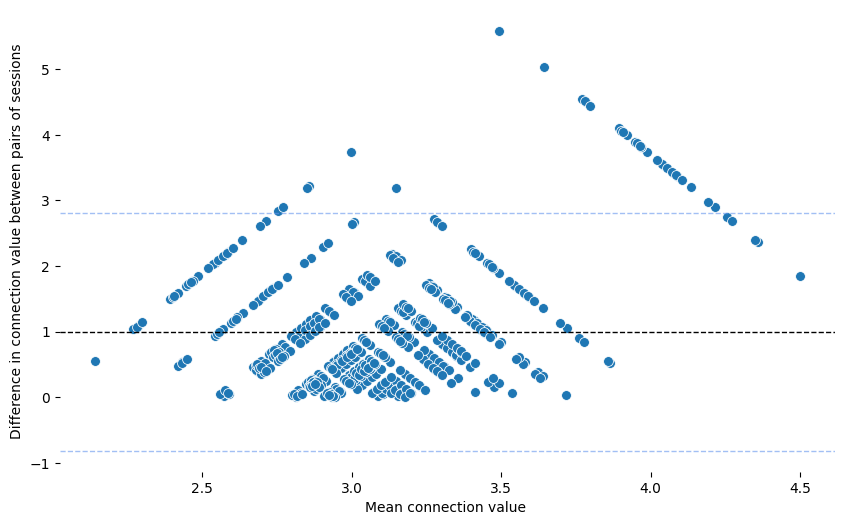

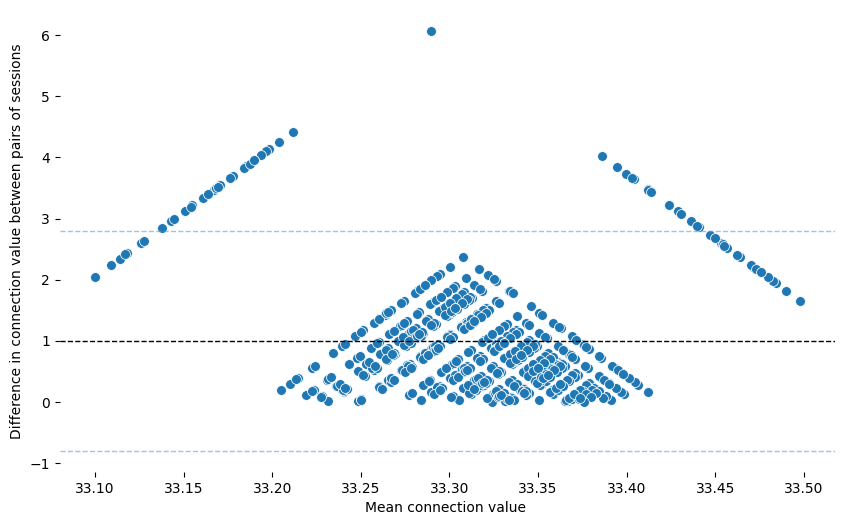

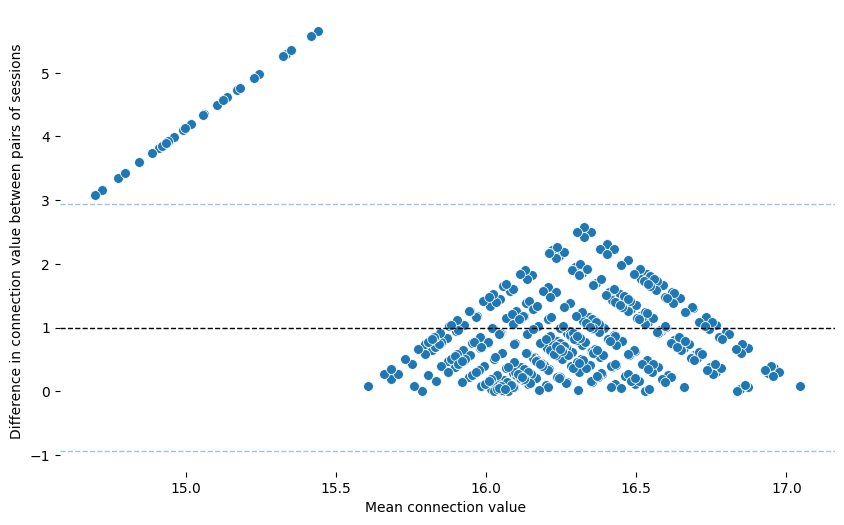

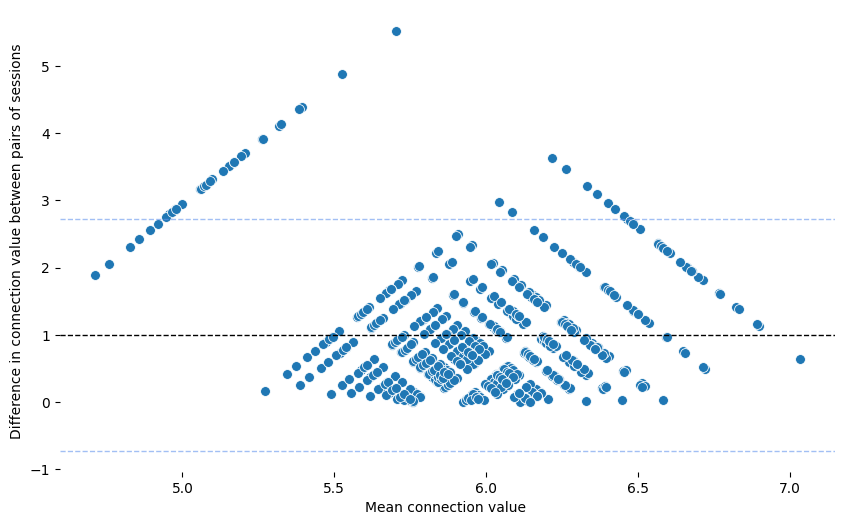

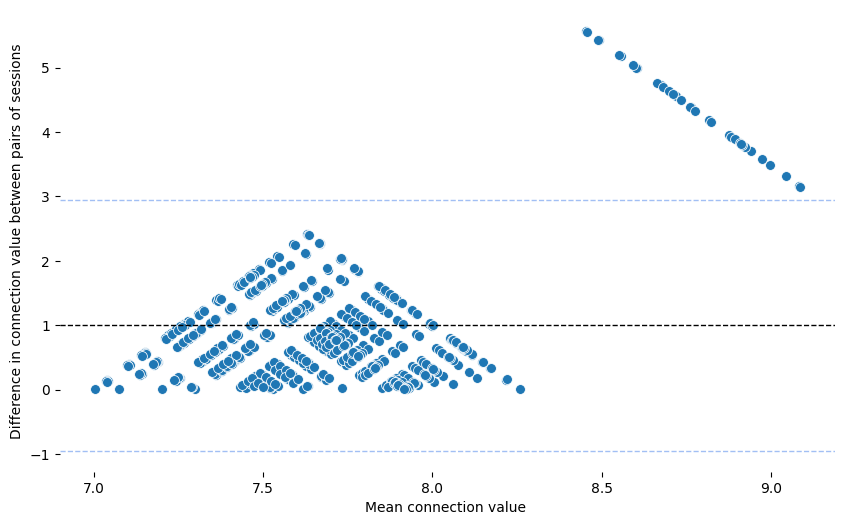

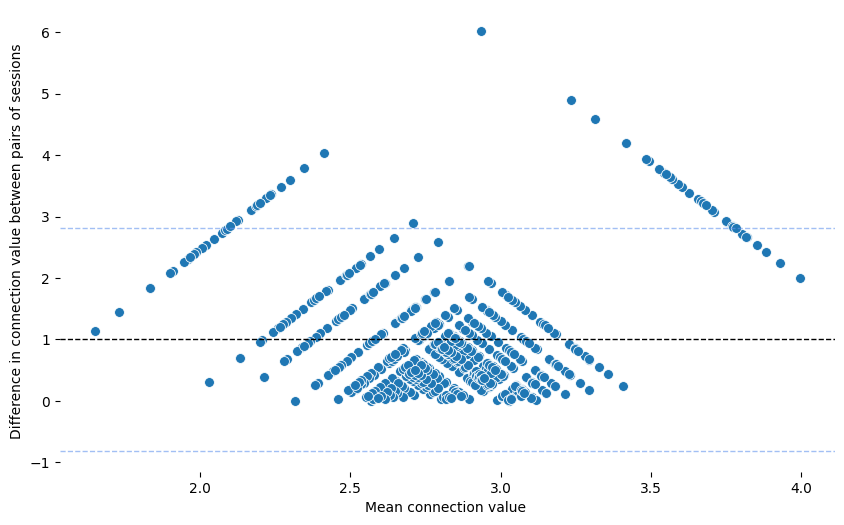

In [25]:
for conn in np.unique(max_indices[1]):
    # Extract the vector of differences and means
    conn_diff = sessions_subtractions[:, conn]
    SC_value = SC_matrices_tril[:, conn]
    conn_mean = sessions_means[:, conn]
    assert conn_mean.shape == (num_sub,)
    assert (
        conn_diff.shape == conn_mean.shape
    ), f"The mean vector has a shape of {conn_mean.shape} while the difference vector has a shape of {conn_diff.shape}."

    # Plot the corresponding BA plot
    ba_plot(
        diff=conn_diff,
        mean=conn_mean,
    )

## Multivariate BA plot

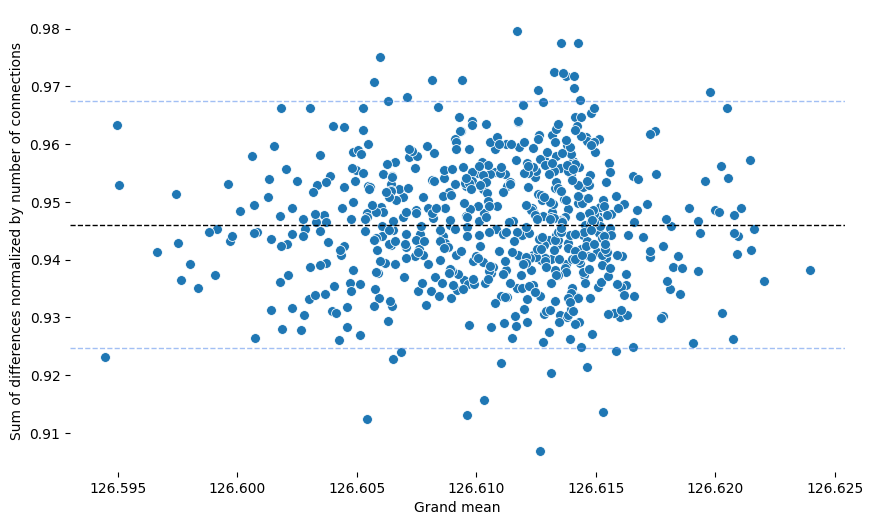

In [26]:
sum_diff = np.sum(sessions_subtractions, axis=1)
sum_diff /= SC_matrices_tril.shape[1]
# Grand mean of SC values in pairs of SC matrices
grand_mean = np.mean(sessions_means, axis=1)
assert sum_diff.shape == (num_sub,)
assert grand_mean.shape == (num_sub,)

ba_plot(diff=sum_diff, mean=grand_mean, xlabel= "Grand mean", ylabel="Sum of differences normalized by number of connections")

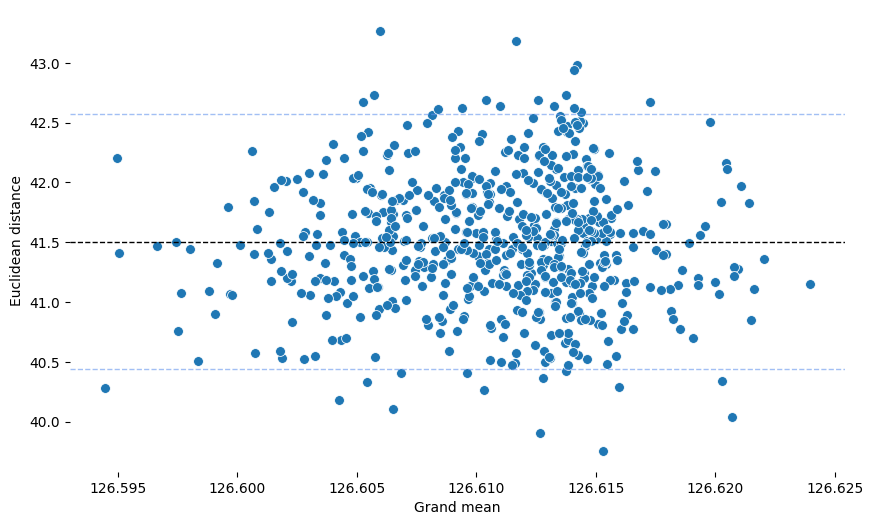

In [27]:
ba_plot(
    diff=sessions_dist,
    mean=grand_mean,
    xlabel="Grand mean",
    ylabel="Euclidean distance",
)

## BA plot with all connections, all pair-wise session comparisons

In [28]:
with h5py.File(atlas_path, "r") as f:
    length_matrix = np.array(f["matrices"]["length"])

length_tril = length_matrix[np.tril_indices(atlas_dim, k=-1)]


print(length_tril.shape)

(4465,)


In [29]:
# Compute all pairwise mean for unique pairs (i, j) where i < j
sessions_means = []
for i in range(num_sessions):
    for j in range(i + 1, num_sessions):
        means = np.mean(np.vstack((SC_matrices_tril[i], SC_matrices_tril[j])), axis=0)
        sessions_means.append(means)

sessions_means = np.array(sessions_means)
sessions_means.shape

(630, 4465)

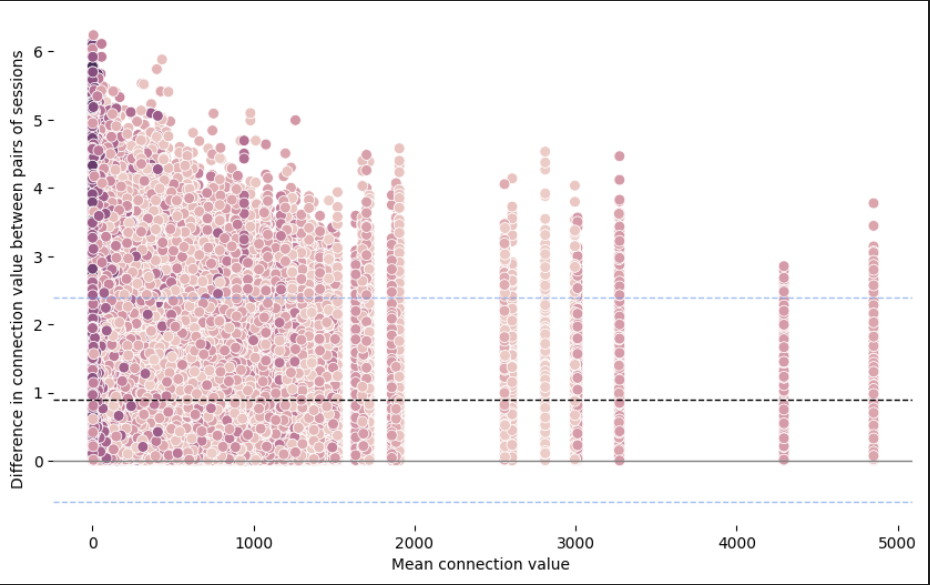

In [30]:
from IPython.display import Image, display

# length_hue = np.tile(length_tril, num_sessions * (num_sessions - 1) // 2)
# np.testing.assert_array_equal(length_hue[:len(length_tril)], length_tril)

# ba_plot(
#     diff = sessions_subtractions.flatten(),
#     mean = sessions_means.flatten(),
#     hue = length_hue,
# )
# Display the photo
image_path = (
    "/home/cprovins/Documents/HCPh_analysis/BAplot_allconnections_lengthhue.png"
)
display(Image(filename=image_path))